### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [1]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS, Chroma
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from sklearn.metrics.pairwise import cosine_similarity
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os
import operator

c:\Users\Nitro\Desktop\Desk\AITutor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

### Supervisor and Workers:- 

##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

##### The supervisor should route the task to the corresponding agent in such a way that the whole task could be done by the agent in and no other agent's capable work should be given to the agent. Such prompt should be given to the supervisor agent.

##### Each agent will get the task that only belongs to it and then when the agent does its work then the agent will change the state due to which the supervisor can get all the changes done by the agent and go for the next job to delegate.

##### It's just like the Orchestrator.

### tools

In [3]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
        model="llama-3.3-70b-versatile"
)

embedding_model = OllamaEmbeddings(model="llama3.2")

# llm = ChatNVIDIA(
#   model="openai/gpt-oss-20b",
#   api_key="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", 
#   temperature=1,
#   top_p=1,
#   max_tokens=4096,
# )


# llm = ChatOllama(model = "llama3.2")

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "What is llm?"})

{'query': 'What is llm?',
 'follow_up_questions': None,
 'answer': 'A large language model (LLM) is an AI system that generates and understands human language. It is trained on vast datasets to perform tasks like answering questions and writing content. LLMs use neural networks for processing.',
 'images': [],
 'results': [{'url': 'https://ask.library.arizona.edu/faq/407985',
   'title': 'What is a large language model (LLM)?',
   'content': '## What is a large language model (LLM)?\n\nA large language model (LLM) is a type of artificial intelligence that can generate human language and perform related tasks. These models are trained on huge datasets, often containing billions of words. By analyzing all this data, the LLM learns patterns and rules of language, similar to the way a human learns to communicate through exposure to language. LLMs can perform various language tasks, such as answering questions, summarizing text, translating between languages, and writing content.\n\nSome ex

In [4]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
materials_tools = []
materials_tools_by_name = {tool.name : tool for tool in materials_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [5]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools([tavily_research_tool])
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(materials_tools)


#### RAG tool:

#### document loader:

In [6]:
# for now, just use the file from the folder (no selection)
pdfLoader = PyPDFLoader(file_path="Attention.pdf")
documents = pdfLoader.load()
print("The documents are:")
for i in documents:
    print(i.page_content)
    print("✨"*50)

The documents are:
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗†
University of Toronto
aidan@cs.toronto.edu
Łukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrence and convolutions
entirely. Experiments on two machine translation tasks show these models to
be superior in quality while being more parallelizable and requiring signiﬁcantly
less time to

In [7]:
# since each of the chunk or the document is large (more uneccessary tokens consumed and more dilution of context)
chunking = RecursiveCharacterTextSplitter(chunk_size = 200, chunk_overlap = 80)
chunks = chunking.split_documents(documents)

processed_chunks = []
for chunk in chunks:
    processed_chunks.append(chunk.page_content)
print(processed_chunks)

['Attention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research', 'Niki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu', 'llion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszkaiser@google.com\nIllia Polosukhin∗‡\nillia.polosukhin@gmail.com\nAbstract', 'lukaszkaiser@google.com\nIllia Polosukhin∗‡\nillia.polosukhin@gmail.com\nAbstract\nThe dominant sequence transduction models are based on complex recurrent or', 'The dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. The best', 'convolutional neural networks that include an encoder and

In [8]:
# vector store and retriever 
vectorStore = Chroma.from_documents(
    documents=chunks,
    embedding= embedding_model,
    collection_name = "DB_Store",
)

# retriever
retriever = vectorStore.as_retriever(search_type = "mmr", search_kwargs = {'k' : 2, 'fetch_k' : 5, 'lambda_mult' : 0.7})

In [9]:
class Output(BaseModel):
    summary : str = Field(description="Contains the summary of the relevant document")

output_schema = PydanticOutputParser(pydantic_object=Output)
# tool for RAG
@tool()
def Retriever(query : str):
    '''Retriever for retrieving relevant documents from user provided document'''
    relevant_documents = retriever.invoke(query)
    page_content = []
    for doc in relevant_documents:
        page_content.append(doc.page_content)
    print(page_content)
    prompt = ChatPromptTemplate.from_messages([
        ('system', """You are a good summarizer that can summarize the relevant documents provided that are extracted from user provided document with the user query\n "
        ****strucutre*** 
         {format}\n
        ****RULES****
         - You are only allowed to use your reasoning knowledge to summarize the relevant documents with the help of qeury
         - Dont go out of the context"""),
        ("human", "Query : {query} \n relevant _documents : {relevant_documents}")
    ]).partial(format = output_schema.get_format_instructions())
    chain = prompt | llm | output_schema
    result = chain.invoke({'query' : query, "relevant_documents" : relevant_documents})
    return result.summary

Retriever.name
Retriever.description
Retriever.args

{'query': {'title': 'Query', 'type': 'string'}}

In [10]:
ans = Retriever.invoke({'query' : "What is self attention"})
ans

['convolutional neural networks that include an encoder and a decoder. The best\nperforming models also connect the encoder and decoder through an attention', 'has been crucially involved in every aspect of this work. Noam proposed scaled dot-product attention, multi-head']


'Self-attention, also known as scaled dot-product attention, is a mechanism that allows a model to attend to different parts of the input sequence simultaneously and weigh their importance. It is a key component of the Transformer model, which replaces traditional recurrent and convolutional neural networks with an attention mechanism. The self-attention mechanism calculates the weighted sum of the input elements, where the weights are learned based on the input elements themselves.'

In [11]:
text1 = "I want to eat something."
text2 = "He is a good actor"
embed1 = embedding_model.embed_query(text1)
embed2 = embedding_model.embed_query(text2)
docs = ["He is a good actor", "I am hungry", "THose were some good times"]
embed3 = embedding_model.embed_documents(docs)
print('text1', embed1)
print('text2', embed2)
print(cosine_similarity([embed1], [embed2]))
print(cosine_similarity([embed1], embed3))

text1 [0.007939801, -0.0059426446, -0.012426561, 0.0048484905, 0.0076550543, -0.0056277504, 0.006526554, 0.020698689, -0.0022364443, -0.0068498715, 0.02310797, -0.0021902972, 0.020467026, 0.02392882, 0.0034688031, 0.0037630722, 0.015151097, -0.01493498, 0.01695271, 0.004284904, -0.005790315, -0.01864791, 0.012727306, -0.020085607, 0.00052976306, -0.0062090075, 0.01927487, 0.024640646, 0.017364744, 0.0027662793, -0.012066266, 0.021864945, -0.004023597, 0.008527502, 0.0025194595, -0.0028812003, -0.023016347, -0.003387797, -0.00034348122, -0.013505806, -0.027654702, -0.00074854965, 0.0334396, 0.014771395, -0.0264475, -0.02110156, -0.0034206589, 0.0047734017, 0.014525608, -0.008503908, 0.0037416182, -0.00236762, -0.0035328872, -0.004720454, -0.0082404455, -0.015340274, 0.005448753, -0.013619751, -0.0038540452, 0.011918336, 0.014614217, 0.009702484, -0.004342364, -0.01434936, 0.03699074, -0.035600275, -0.005302279, -0.0077824476, -0.0033712087, -0.0042716195, -0.0067790546, 0.004019507, 3.2

In [110]:
# BaseModels

class Task(BaseModel):
    '''contains information of each step of the plan'''
    id : int = Field(description="id of the step")
    goal : str = Field(description="goal that the user needs to reach after reding the task's answer")
    tool_required : bool = Field("True if research tool is required and False if not")

task_schema = PydanticOutputParser(pydantic_object=Task)

class Plan(BaseModel):
    '''list of plan'''
    plan : list[Task]

plan_schema = PydanticOutputParser(pydantic_object=Plan)

class Goal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    # title : str = Field(description = "name or title based upon the user query")
    id : int = Field(description = "id of the agent in integer")
    agent : Literal['Researcher', 'RAG', 'TaskSpecific', 'YoutubeAgent', 'END'] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

sub_goal_schema = PydanticOutputParser(pydantic_object=Goal)

class RAG_agent_type(BaseModel):
    pass


class Youtube_agent_type(BaseModel):
    pass


class StudyStep(BaseModel):
    id : int = Field(description="step of the plan")
    sub_goal : str = Field(description="goal of step to teach the learner about")

class StudyPlannerModel(BaseModel):
    plan : list[StudyStep]

study_step_schema = PydanticOutputParser(pydantic_object=StudyStep)
study_planner_schema = PydanticOutputParser(pydantic_object=StudyPlannerModel)

class QAandFlashCardsModel(BaseModel):
    question : list

class MaterialGoal(BaseModel):
    '''contains the goal for the particualr agent with name of the agent'''
    # title : str = Field(description = "name or title based upon the user query")
    id : int = Field(description = "id of the agent in integer")
    agent : Literal['QAandFlashCards', "StudyPlanner", "END"] = Field(description="one specific agent that is to be choosen for the work")
    sub_goal : str = Field(description = "goal that is provided the to the specific one agent")

material_sub_goal_schema = PydanticOutputParser(pydantic_object=MaterialGoal)

In [111]:
# id and agent_name
mapper = {
    1 : 'Researcher',
    5 : 'END'
}

material_mapper = {
    1 : "QAandFlashCards",
    2 : "StudyPlanner",
    3 : "END"
}

# Research Graph
class ResearchState(TypedDict):
    # Sub-goal given by the supervisor
    sub_goal : str
    # plan made by the researcher agent
    agent_plan : Annotated[list[Task], operator.add]
    # explaination done by agent (either toolMessage or the AiMessage)
    agent_explain : Annotated[list[str], operator.add]
    # key points covered by this agent
    key_points : Annotated[list[str], operator.add]


class StudyPlannerState(TypedDict):
    goal : str
    key_points : list[str] = Field(description="contains the key points of the plan of the topic to study made by the studyPlanner")
    content : StudyPlannerModel

class QAandFlashCardsState(TypedDict):
    goal : str
    content : QAandFlashCardsModel


# MaterialGraph (Q/A_and_flashcards and study planner))
class MaterialsState(TypedDict):
    # sub-goal given by the supervisor(Helper Supervisor)
    agent_id : Annotated[list[int], add_messages]
    sub_goal : str
    StudyPlanner : StudyPlannerState
    QAandFlashCards : QAandFlashCardsState


class RAGState(TypedDict):
    pass

class YoutubeState(TypedDict):
    pass

# Main State
class State(TypedDict):
    goal : str
    title : str
    need_RAG : bool
    agent_ids : Annotated[list[int], operator.add]
    Researcher : ResearchState
    YoutubeAgent : Youtube_agent_type
    TaskSpecific : MaterialsState


In [14]:
def Planner(state : ResearchState):
    goal = state['sub_goal']
    # prompt = PromptTemplate(template="goal : {sub_goal} \n\n{format}", input_variables=['sub_goal'], partial_variables={"format" : task_schema.get_format_instructions()})
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You as an excellent planner agent that can generate a beautiful productive plan to give to the worker agents to execute on the basis of your plan. Workers agents will explain based on you plan so make the plan good. 
         Total number of steps must be less than 7. \n
         
         ****TOOL USAGE RULE****
            Set "tool_required" = true ONLY if the goal includes ANY time-dependent intent.

            Time-dependent means:
            - current
            - latest
            - recent
            - today
            - now
            - trending
            - live
            - real-time
            - updated information

            If ANY of these appear or are implied → tool_required = true

            Otherwise (theoretical, general, timeless knowledge) → tool_required = false

            You MUST strictly follow this mapping.\n
                    
         ***Structure***
         Just give me list of steps in the following JSON format:\n
        {plan}\n\n
         where each task is in the form of:\n
         {task}"""),
        ("human", "Goal : {goal}")]).partial(plan = plan_schema.get_format_instructions(), task = task_schema.get_format_instructions())
    chain = prompt | llm | plan_schema
    plan = chain.invoke({'goal' : goal}).plan
    print(plan)
    key_points = []
    agent_plan = []
    for step in plan:
        agent_plan.append({
            'id' : step.id,
            'goal' : step.goal,
            'tool_required' : step.tool_required
        })
        key_points.append(step.goal)
    print(agent_plan)
    return {'agent_plan' : agent_plan, 'key_points' : key_points}

In [15]:
Planner(ResearchState(sub_goal="RNN"))

[Task(id=1, goal='Introduce the concept of RNN and its basic architecture', tool_required=False), Task(id=2, goal='Explain how RNNs process sequential data', tool_required=False), Task(id=3, goal='Discuss the applications of RNNs', tool_required=False), Task(id=4, goal='Describe common challenges faced by RNNs and solutions like LSTM and GRU', tool_required=False), Task(id=5, goal='Provide examples or case studies of RNNs in action', tool_required=False), Task(id=6, goal='Summarize the future of RNNs and their potential evolution', tool_required=False)]
[{'id': 1, 'goal': 'Introduce the concept of RNN and its basic architecture', 'tool_required': False}, {'id': 2, 'goal': 'Explain how RNNs process sequential data', 'tool_required': False}, {'id': 3, 'goal': 'Discuss the applications of RNNs', 'tool_required': False}, {'id': 4, 'goal': 'Describe common challenges faced by RNNs and solutions like LSTM and GRU', 'tool_required': False}, {'id': 5, 'goal': 'Provide examples or case studies 

{'agent_plan': [{'id': 1,
   'goal': 'Introduce the concept of RNN and its basic architecture',
   'tool_required': False},
  {'id': 2,
   'goal': 'Explain how RNNs process sequential data',
   'tool_required': False},
  {'id': 3,
   'goal': 'Discuss the applications of RNNs',
   'tool_required': False},
  {'id': 4,
   'goal': 'Describe common challenges faced by RNNs and solutions like LSTM and GRU',
   'tool_required': False},
  {'id': 5,
   'goal': 'Provide examples or case studies of RNNs in action',
   'tool_required': False},
  {'id': 6,
   'goal': 'Summarize the future of RNNs and their potential evolution',
   'tool_required': False}],
 'key_points': ['Introduce the concept of RNN and its basic architecture',
  'Explain how RNNs process sequential data',
  'Discuss the applications of RNNs',
  'Describe common challenges faced by RNNs and solutions like LSTM and GRU',
  'Provide examples or case studies of RNNs in action',
  'Summarize the future of RNNs and their potential evo

In [16]:
def Researcher(state : ResearchState):
    plan = state['agent_plan']
    explaination = []
    prompt = ChatPromptTemplate.from_messages([
        ('system', """
    You are a **Research & Explanation Agent**.

    You will receive **one task at a time**. Your job is to produce content that directly satisfies the goal.
    Rules:
    - Focus only on the current task. Do not explain unrelated concepts.
    - Adapt explanation to goal type: definition, math, numeric example, summary, etc.
    - Output concise, relevant explanation. No forced headings, templates, or extra text.
    """),
        ('human', "task : {task}")
    ])
    for step in plan:
        print(step)
        if step['tool_required'] == True:
            # do the llm call with the tool_required
            output = research_agent_with_tool.invoke(step['goal'])
            if not output.tool_calls :
                print("⚠️No tools called despite of the tool_required : TRUE")
                print(output.content)
            else:
                tool_recommended = output.tool_calls[0]
                tool_name = research_tools_by_name[tool_recommended['name']]
                tool_output = tool_name.invoke(tool_recommended['args'])['answer']
                print(tool_output)
                explaination.append(tool_output)
        else:
            chain = prompt | llm | StrOutputParser()
            # result = chain.invoke(step['goal'])
            message = HumanMessage(content=step['goal'])  # wrap goal
            result = chain.invoke([message])              
            print(result)
            explaination.append(result)

    return {'agent_explain' : explaination}

In [17]:
Researcher({'agent_plan': [{'id': 1,
   'goal': 'Identify current trends in AI',
   'tool_required': True},
  {'id': 2,
   'goal': 'Analyze recent developments in AI research',
   'tool_required': True},
  {'id': 3,
   'goal': 'Explore applications of AI in various industries',
   'tool_required': False},
  {'id': 4,
   'goal': 'Summarize key findings and insights on AI trends',
   'tool_required': False},
  {'id': 5,
   'goal': 'Provide recommendations for future AI research and development',
   'tool_required': False},
  {'id': 6,
   'goal': 'Present the final report on AI trends',
   'tool_required': False}]})

{'id': 1, 'goal': 'Identify current trends in AI', 'tool_required': True}
Current AI trends include conversational AI, generative AI, and edge AI for real-time processing. Smaller, cost-effective models are becoming popular. Auto-ML platforms are simplifying AI model creation.
{'id': 2, 'goal': 'Analyze recent developments in AI research', 'tool_required': True}
Recent developments in AI research highlight a significant focus on generative AI, with 56% of executives expecting it to improve customer satisfaction, loyalty, engagement, and retention. However, practitioners are more interested in automating repetitive tasks and workflows, with 46% wanting AI for this purpose compared to 41% of executives. Additionally, 36% of practitioners expect AI to accelerate content creation and activation, contrasting with only 14% of top executives. The "Declaration of Humanity" initiative in the US emphasizes prioritizing human interests in AI development, stressing the need for safety confirmation

{'agent_explain': ['Current AI trends include conversational AI, generative AI, and edge AI for real-time processing. Smaller, cost-effective models are becoming popular. Auto-ML platforms are simplifying AI model creation.',
  'Recent developments in AI research highlight a significant focus on generative AI, with 56% of executives expecting it to improve customer satisfaction, loyalty, engagement, and retention. However, practitioners are more interested in automating repetitive tasks and workflows, with 46% wanting AI for this purpose compared to 41% of executives. Additionally, 36% of practitioners expect AI to accelerate content creation and activation, contrasting with only 14% of top executives. The "Declaration of Humanity" initiative in the US emphasizes prioritizing human interests in AI development, stressing the need for safety confirmation before use, especially for applications intended for young people. Meanwhile, a new benchmark developed by nearly 1,000 researchers aim

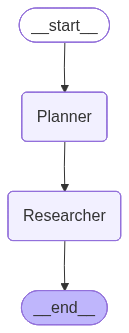

In [18]:
researchGraph = StateGraph(ResearchState)

researchGraph.add_node("Planner", Planner)
researchGraph.add_node("Researcher", Researcher)

researchGraph.add_edge(START, "Planner")
researchGraph.add_edge("Planner", "Researcher")
researchGraph.add_edge("Researcher", END)

ResearcherSubGraph = researchGraph.compile()
ResearcherSubGraph

In [19]:
ResearcherSubGraph.invoke({'sub_goal' : "explain self sttention clearly"})

[Task(id=1, goal='Introduce the concept of self-attention', tool_required=False), Task(id=2, goal='Explain the definition and purpose of self-attention in neural networks', tool_required=False), Task(id=3, goal='Describe the self-attention mechanism and its components (Query, Key, Value)', tool_required=False), Task(id=4, goal='Provide a step-by-step example or illustration of how self-attention works', tool_required=False), Task(id=5, goal='Highlight the benefits and applications of self-attention in deep learning models', tool_required=False), Task(id=6, goal='Summarize the key points and takeaways about self-attention', tool_required=False)]
[{'id': 1, 'goal': 'Introduce the concept of self-attention', 'tool_required': False}, {'id': 2, 'goal': 'Explain the definition and purpose of self-attention in neural networks', 'tool_required': False}, {'id': 3, 'goal': 'Describe the self-attention mechanism and its components (Query, Key, Value)', 'tool_required': False}, {'id': 4, 'goal': '

{'sub_goal': 'explain self sttention clearly',
 'agent_plan': [{'id': 1,
   'goal': 'Introduce the concept of self-attention',
   'tool_required': False},
  {'id': 2,
   'goal': 'Explain the definition and purpose of self-attention in neural networks',
   'tool_required': False},
  {'id': 3,
   'goal': 'Describe the self-attention mechanism and its components (Query, Key, Value)',
   'tool_required': False},
  {'id': 4,
   'goal': 'Provide a step-by-step example or illustration of how self-attention works',
   'tool_required': False},
  {'id': 5,
   'goal': 'Highlight the benefits and applications of self-attention in deep learning models',
   'tool_required': False},
  {'id': 6,
   'goal': 'Summarize the key points and takeaways about self-attention',
   'tool_required': False}],
 'agent_explain': ['Self-attention is a mechanism used in deep learning, particularly in transformer-based architectures. It allows a model to attend to different parts of the input sequence simultaneously an

In [119]:
class MaterialsState(TypedDict):
    # sub-goal given by the supervisor(Helper Supervisor)
    agent_ids : Annotated[list[int], add_messages]
    sub_goal : str
    StudyPlanner : StudyPlannerState
    QAandFlashCards : QAandFlashCardsState

def MiniSuervisor(state : MaterialsState):
    # get the sub-goal from the user and this will chose which agent to route the goal to with what goal.
    sub_goal = state['sub_goal']
    agent_ids = state.get("agent_ids", [])
    record = {}
    for agent_id in material_mapper:
        if agent_id in agent_ids:
            record[material_mapper[agent_id]] = "occupied"
        else:
            record[material_mapper[agent_id]] = "free"
    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor Agent who have two agents as the worker agent, and you have to choose one of the agent suitable for the provided goal.\n
        ****Agents with their id, name and work****
        1. QAandFlashCards : Generate Q/A or flaashcards on a topic
        2. StudyPlanner : Used to plan a study roadmap on a topic\n
        
         ****State of the agent****
         {record}
         Note : You cannot use the agent's that are occupied\n

        ****Rule****
         - Analayze the given goal and choose one agent that is required for that.
         - you are only allowed to use one agent.
         - You cannot call agent's that are occupied\n
         
        ****Format****
        {format}"""),
        ("human", "goal : {sub_goal}")
    ]).partial(format = material_sub_goal_schema.get_format_instructions())
    chain = prompt | llm | material_sub_goal_schema
    result = chain.invoke({"record" : record, 'sub_goal' : sub_goal})
    print(result)
    return {'agent_id' : [result.id], result.agent : {'goal' : result.sub_goal}}

def StudyPlanner(state : MaterialsState):
    # gets the goal to make a study plan effectively
    pass

def QAandFlashCards(state : MaterialsState):
    pass

def SubAgentSelection(state : MaterialsState):
    if 1:
        return "QAandFlashCards"
    
    elif 2:
        return "StudyPlanner"
    
    elif 3:
        return "END"

In [121]:
res = MiniSuervisor(MaterialsState(sub_goal="I am going to give interview tomorrow about ml and i dont know the question they are gonna ask for intern level. Help me"))
res

id=1 agent='QAandFlashCards' sub_goal='Generate questions and answers or flashcards on machine learning for intern level interview'


{'agent_id': [1],
 'QAandFlashCards': {'goal': 'Generate questions and answers or flashcards on machine learning for intern level interview'}}

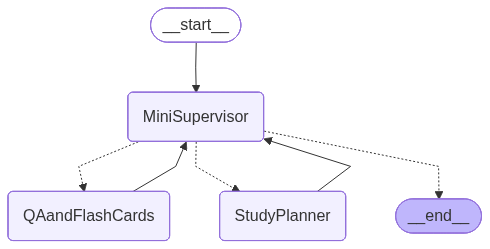

In [39]:
subGraph = StateGraph(MaterialsState)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner"})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")
subGraph.add_edge("MiniSupervisor", END)

subSystem = subGraph.compile()

subSystem

In [22]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    goal = state['goal']
    researcher = state.get('Researcher', {}).get("key_points", [])
    agent_ids = state.get('agent_ids', [])
    record = {}
    for agent_id in mapper:
        if agent_id in agent_ids:
            record[mapper[agent_id]] = "occupied"
        else:
            record[mapper[agent_id]] = "free"

    print(record)
    print("Already used agents :", agent_ids)
    print(goal)
    print(researcher)
    prompt = ChatPromptTemplate([
        ('system', """You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n
         ****Specialized agents(worker agents) id and their speciality****
         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)
         5 --> END : If no any agents is required now.\n\n
        
         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n

         ****Specialized agents(worker agents) name and their work till now*****
         Researcher : {researcher_work}
         
         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn't been used yet. \n\n
         
         ****Agents state****
         {record}

         "free" can be used again
         "occupied" are not accessible
         ****Structure****
    
         To provide the specific agent you have to return the goal in the following structure\n

         {format}\n\n

        ****Rules****
         
         - Don't use already used agents
         - Only provide goal to the specialized agent goal when the query seems to demand.
         - Depending upon the user query, its meaning(as you are Tutor) and work done by workers till now, you must call only the required agent at a time,
         - Dont use the used agent twice.

         """),
        ('human', "Goal/Query from user : {goal}")
    ]).partial(format = sub_goal_schema.get_format_instructions(), researcher_work  = researcher, record = record)
    print("⚠️"*50)
    print(prompt.invoke({'goal' : goal}))
    print("⚠️"*50)
    # Generate the title for it
    chain = prompt | llm | sub_goal_schema
    response = chain.invoke({'goal' : goal})
    print(type(response.id))
    print("next agent ---> ", response.id)
    print('Supervisor Completed ✅')
    return {'agent_ids' : [response.id], response.agent : {'sub_goal' : response.sub_goal}}

In [23]:
Supervisor(State(goal="Self-Attention"))

{'Researcher': 'free', 'END': 'free'}
Already used agents : []
Self-Attention
[]
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
messages=[SystemMessage(content='You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n\n         ****Specialized agents(worker agents) id and their speciality****\n         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)\n         5 --> END : If no any agents is required now.\n\n\n\n         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n\n\n         ****Specialized agents(worker agents) name and their work till now*****\n         Researcher : []\n\n         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn\'t been used yet. \n\n\n\n         ****Agents state****\n         {\'Researcher\': \'free\', \'END\': \'f

{'agent_ids': [1],
 'Researcher': {'sub_goal': 'Research and provide detailed information about Self-Attention, including its definition, mechanism, and applications in deep learning and natural language processing.'}}

In [24]:
# FOR THE RESEARCH NODE
# it should be complex as its job is not only to extract one knowledge but many aspects like what, how, why, when, exmaples, mechanism etc.
def Researcher(state : State):
    sub_goal = state['Researcher']['sub_goal']
    print("Researcher agent's Goal: ",sub_goal)
    response = ResearcherSubGraph.invoke({'sub_goal' : sub_goal})
    print(response)
    print('Research Completed ✅')
    return {'Researcher' : {
        'sub_goal' : response['sub_goal'],
        'agent_plan' : response['agent_plan'],
        'agent_explain' : response['agent_explain'],
        'key_points' : response['key_points']
    }}

In [25]:
Researcher(State(Researcher= {
    'sub_goal' : "Self Attention",
}))

Researcher agent's Goal:  Self Attention
[Task(id=1, goal='Define Self Attention and its purpose in deep learning models', tool_required=False), Task(id=2, goal='Explain the mechanism of Self Attention, including query, key, and value vectors', tool_required=False), Task(id=3, goal='Describe the role of Self Attention in transformer models', tool_required=False), Task(id=4, goal='Provide examples of how Self Attention is used in real-world applications', tool_required=False), Task(id=5, goal='Discuss the advantages and limitations of using Self Attention in models', tool_required=False), Task(id=6, goal='Summarize key points about Self Attention for future reference', tool_required=False)]
[{'id': 1, 'goal': 'Define Self Attention and its purpose in deep learning models', 'tool_required': False}, {'id': 2, 'goal': 'Explain the mechanism of Self Attention, including query, key, and value vectors', 'tool_required': False}, {'id': 3, 'goal': 'Describe the role of Self Attention in transfo

{'Researcher': {'sub_goal': 'Self Attention',
  'agent_plan': [{'id': 1,
    'goal': 'Define Self Attention and its purpose in deep learning models',
    'tool_required': False},
   {'id': 2,
    'goal': 'Explain the mechanism of Self Attention, including query, key, and value vectors',
    'tool_required': False},
   {'id': 3,
    'goal': 'Describe the role of Self Attention in transformer models',
    'tool_required': False},
   {'id': 4,
    'goal': 'Provide examples of how Self Attention is used in real-world applications',
    'tool_required': False},
   {'id': 5,
    'goal': 'Discuss the advantages and limitations of using Self Attention in models',
    'tool_required': False},
   {'id': 6,
    'goal': 'Summarize key points about Self Attention for future reference',
    'tool_required': False}],
  'agent_explain': ['Self-attention, also known as intra-attention, is a mechanism used in deep learning models to weigh the importance of different parts of the input data relative to e

In [26]:
def YoutubeVideos(state : State):
    pass

In [38]:
# FOR THE YOUTUBEVIDEOS NODE
def Materials(state : State):
    # We make subgraph as it will contain multiple agents in side the TaskSpecific agent:
    # Worker Agents:
        # Q/A and FlashCards
        # StudyPlanner
    # All agents will have same tool as not needed much
    output = subSystem.invoke({})
    pass

In [28]:
# FOR THE RAG AGENT
def RAG(state : State):
    # we have retriever that is used to retrieve the corresponding queries asnwer from the document
    pass

In [29]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    print("Synthesizer ✅")

    return {}
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form

In [30]:
def AgentSelection(state : State):
    print("AGENT IDS", state.get("agent_ids"), [])
    agent_id = state['agent_ids'][-1]
    print("agent id",type(agent_id))
    print("next ---->", agent_id)
    if agent_id == 1:
        return "Researcher"
    elif agent_id == 2: 
        return "RAG"
    elif agent_id == 3:
        return "TaskSpecific"
    elif agent_id == 4:
        return "YoutubeAgent"
    else:
        return "Synthesizer"

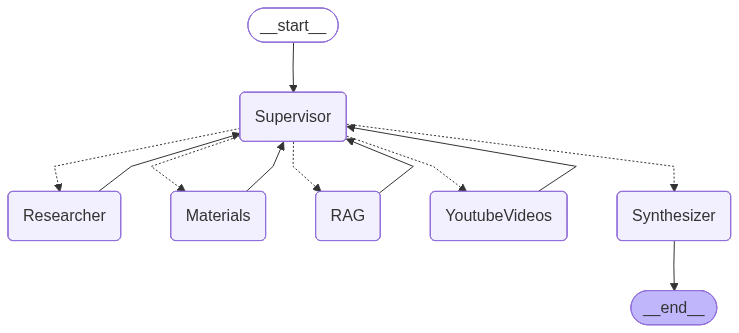

In [35]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("Materials", Materials)    
graph.add_node("RAG", RAG)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "YoutubeVideos" : "YoutubeVideos", "Materials" : "Materials", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Materials", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

MainGraph = graph.compile()

MainGraph



In [32]:
MainGraph.invoke({'goal' : "Self-attention"})

{'Researcher': 'free', 'END': 'free'}
Already used agents : []
Self-attention
[]
⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️⚠️
messages=[SystemMessage(content='You are a supervisor agent for an AI Tutor and you have a bunch of specialized agents:\n\n\n         ****Specialized agents(worker agents) id and their speciality****\n         1 --> Researcher : Research on the topics (research that required llm knowledge and research tools)\n         5 --> END : If no any agents is required now.\n\n\n\n         Now you have to choose one of the above agents based upon the user query and agent specialization/use. \n\n\n\n         ****Specialized agents(worker agents) name and their work till now*****\n         Researcher : []\n\n         Very important Note : If there is [] with no elements in any of the agent, that means the agent hasn\'t been used yet. \n\n\n\n         ****Agents state****\n         {\'Researcher\': \'free\', \'END\': \'f

{'goal': 'Self-attention',
 'agent_ids': [1, 5],
 'Researcher': {'sub_goal': 'Research and provide information on Self-attention, particularly its application in deep learning and natural language processing.',
  'agent_plan': [{'id': 1,
    'goal': 'Understand the concept of self-attention and its significance in deep learning',
    'tool_required': False},
   {'id': 2,
    'goal': 'Research the application of self-attention in natural language processing (NLP)',
    'tool_required': True},
   {'id': 3,
    'goal': 'Investigate the use of self-attention in popular deep learning models such as Transformers',
    'tool_required': True},
   {'id': 4,
    'goal': 'Gather information on the benefits and limitations of using self-attention in deep learning and NLP',
    'tool_required': True},
   {'id': 5,
    'goal': 'Compile and summarize the findings on self-attention and its applications',
    'tool_required': False}],
  'agent_explain': ["Self-attention is a mechanism in deep learning 

In [33]:
output = research_agent_with_tool.invoke("What is the top 10 news on Nepal right now!")
output.tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'top 10 news on Nepal now',
   'search_depth': 'advanced',
   'topic': 'news'},
  'id': 'fc5d3gy6y',
  'type': 'tool_call'}]

In [34]:
output

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fc5d3gy6y', 'function': {'arguments': '{"query":"top 10 news on Nepal now","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 2113, 'total_tokens': 2165, 'completion_time': 0.124592204, 'completion_tokens_details': None, 'prompt_time': 0.061225604, 'prompt_tokens_details': None, 'queue_time': 0.045159105, 'total_time': 0.185817808}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_37da608fc1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d0adb-4f19-7fa2-ae46-03cc22b7deae-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'top 10 news on Nepal now', 'search_depth': 'advanced', 'topic': 'news'}, 'id': 'fc5d3gy6y', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens':